# Estimate absorption coefficient ($\mu_a$) using Beer-Lambert for non-scattering samples and load IAD $\mu_a$ and $\mu_s^{'}$ spectra

Characterisation of the absorption coefficient ($\mu_a$) of H2O, D2O, DMSO, synthetic melanin, corn oil, oxygenated and deoxygenated haemoglobin using Beer-Lambert

Estimate $\mu_a$ using Beer-Lambert Law with cuvettes of 2 pathlengths:

$T_1/T_2 = f_{cal} * \exp(-\mu_a(l_1-l_2))$

thus

$\mu_a = - (1/(l_1-l_2))*ln(T_1/T_2) $

Assumes $F_{cal}$ = 1 since using the same beam for all measurements.

Transmission measured with Shimadzu UV-vis spectrophotometer with single integrating sphere (SIS) attachment. 

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import curve_fit

# Functions to process spectra

In [2]:

#---------------------------------------------------------------------------------------------------------------------------------
# function to estimate mua from transmission measurements from one sample, want mu_a in cm^-1 so input l1 and l2 in cm, in my experiments, 
# both samples were measured in the same sample port of the SIS
def estimate_mua(path, T1, T2, l1, l2):
    "path: path to csv,"
    "T1 & T2: list of header names for 1mm & 2mm cuvette indep. repeats,"
    "l1 & l2: path lengths of cuvettes for T1 & T2 measurements"

    # load csv file with the transmission data
    df = pd.read_csv(path, sep=",", skiprows=0, header=0)

    # find wavelength column [nm]
    wavelengths = df['Wavelength_nm']
    
    # find mean average and standard deviation transmission of the 3 (indep.) measurements of the sample in 1mm cuvette [%]
    T1_mean = df[T1].mean(axis=1)
    T1_std = df[T1].std(axis=1)

    # find mean average and standard deviation transmission of the 3 (indep.) measurements of the sample in 2mm cuvette [%]
    T2_mean = df[T2].mean(axis=1)
    T2_std = df[T2].std(axis=1)

    # plug into Beer-Lambert law
    mua_estimate = -np.log(T1_mean/T2_mean) / (l1-l2)

    # estimate standard deviation in mua
    mua_std = (1/(l1-l2)) * np.sqrt((T1_std/T1_mean)**2 + (T2_std/T2_mean)**2)

    return wavelengths, mua_estimate, mua_std
    
#---------------------------------------------------------------------------------------------------------------------------------
# function to remove zeros, NaNs and values less than 0.001
def clean_df(df):
    "df: Pandas DataFrame"
    
    df.loc[df["mua"] < 0.001, "mua"] = np.nan # replace mua values less than 0.001 with NaN
    df.loc[df["mua"]+ df["std"]*3 < 0.001, "mua"] = np.nan # replace mua - 3 * mua std values less than 0.001 with NaN
    df.loc[df["mua"]- df["std"]*3 < 0.001, "mua"] = np.nan # replace mua - 3 * mua std values less than 0.001 with NaN
    df = df.replace([np.inf, -np.inf], np.nan) 
    df = df.dropna() # remove NaNs
    
    return df
    
#---------------------------------------------------------------------------------------------------------------------------------
# takes raw data and outputs mua estimate
def process_spectra(path, A2, A1, B2, B1, C2, C1, l1, l2):
    "path: to data, A,B,C_1,2: transmission spectra for samples A,B,C through cuvettes with path length l1,l2"

    # estimate mua in cm-1
    wvl_A, mua_A, std_A = estimate_mua(path, A1, A2, l1, l2)
    wvl_B, mua_B, std_B = estimate_mua(path, B1, B2, l1, l2)
    wvl_C, mua_C, std_C = estimate_mua(path, C1, C2, l1, l2)

    # df with mean and std of technical replicates
    df_mua = pd.DataFrame([mua_A, mua_B, mua_C])
    
    # mean mua
    mua_mean = df_mua.mean(axis=0)
    
    # mua standard deviation
    mua_std = np.sqrt(std_A**2 + std_B**2 + std_C**2)

    # combine data for plotting
    df = pd.DataFrame({"nm": wvl_A, "mua": mua_mean, "std": mua_std}) 
    
    # clean data to remove NaNs etc.
    df = clean_df(df)

    return df

#---------------------------------------------------------------------------------------------------------------------------------
# plots mua and ± standard deviation from df_merged (Shimadzu spectrophotometer data)
def plot_mua(mua_column_name, std_column_name, colour, label):

    df_merged[mua_column_name].plot(c=colour, lw=2, ls='-', label=label)

    plt.fill_between(df_merged.index, df_merged[mua_column_name] - df_merged[std_column_name], df_merged[mua_column_name] 
                     + df_merged[std_column_name], color=colour, lw=2, alpha=0.3, edgecolor=None)
    
    plt.grid(True)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha = 0.5)
    plt.yscale("log")

    plt.ylabel('$\mu_a$ (cm$^{-1}$)',  fontsize=14)
    plt.xlabel('Wavelength (nm)',  fontsize=14)
    plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True, bottom=True)
    plt.minorticks_on()

    return

#---------------------------------------------------------------------------------------------------------------------------------
# plots spectra in df_IAD (from Ran's SIS system)
def plot_mua_IAD(mua_column_name, std_column_name, colour, label):

    df_IAD[mua_column_name].plot(c=colour, lw=2, ls='-', label=label)

    plt.fill_between(df_IAD.index, df_IAD[mua_column_name] - df_IAD[std_column_name], df_IAD[mua_column_name] 
                     + df_IAD[std_column_name], color=colour, lw=2, alpha=0.3)
    
    plt.grid(True)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha = 0.5)
    plt.yscale("log")

    plt.ylabel('$\mu_a$ (cm$^{-1}$)',  fontsize=14)
    plt.xlabel('Wavelength (nm)',  fontsize=14)
    plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)
    plt.minorticks_on()

    return

#---------------------------------------------------------------------------------------------------------------------------------
# function to process IAD data and clean df
def IAD(path, name):

    df = pd.read_csv(path, sep=',', header=[0])
    
    df.loc[df["mua[cm-1]"] < 0.001, "mua[cm-1]"] = np.nan # replace mua values less than 0.001 with NaN
    df.loc[df["mua[cm-1]"]- df["mua_std[cm-1]"] < 0.001, "mua[cm-1]"] = np.nan # replace mua - mua std values less than 0.001 with NaN
    df = df.replace([np.inf, -np.inf], np.nan) 

    df = df.rename(columns={"mua[cm-1]": name + " mua", "mua_std[cm-1]": name + " mua std", "mus[cm-1]": name + " mus", 
                            "mus_std[cm-1]": name + " mus std", "mus_fit[cm-1]": name + " mus fit", "musp[cm-1]": name + " musp", 
                            "musp_std[cm-1]": name + " musp std", "assumed_g": name + " g"})
    
    return df
    
#---------------------------------------------------------------------------------------------------------------------------------

# create array with common wavelength axis to compare measured and literature datasets 
#(remove wavelength data that is not common to both / fit to 2nm interval I measured with)
def mix(x_min, x_max, interval, x_1, y_1, x_2, y_2, pc_1):

    # wavelength range
    x_new = np.arange(x_min, x_max+interval, interval)

    # H2O
    y_1 = np.interp(x_new, x_1, y_1)
    # D2O
    y_2 = np.interp(x_new, x_2, y_2)
    # HDO
    y_mix = pc_1*y_1 + (1-pc_1)*y_2
    
    return x_new, y_mix



In [3]:
BASE_PATH = r'/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/'

# Corn oil

In [4]:
path_cornoil = BASE_PATH + 'Data/Shimadzu/Corn_Oil_250506_MJW.csv'

# Header names of samples for input into estimate_mua function
# sample_1mm = ['A_1mm_1', 'A_1mm_2', 'A_1mm_3'], sample_2mm = ['A_2mm_1', 'A_2mm_2', 'A_3mm_3']
# Corn oil (CO) header names, 3 independant and technical repeats
CO_A_2mm = ['T_2mm_1_1', 'T_2mm_1_2', 'T_2mm_1_3']
CO_A_1mm = ['T_1mm_1_1', 'T_1mm_1_2', 'T_1mm_1_3']

CO_B_2mm = ['T_2mm_2_1', 'T_2mm_2_2', 'T_2mm_2_3']
CO_B_1mm = ['T_1mm_2_1', 'T_1mm_2_2', 'T_1mm_2_3']

CO_C_2mm = ['T_2mm_3_1', 'T_2mm_3_2', 'T_2mm_3_3']
CO_C_1mm = ['T_1mm_3_1', 'T_1mm_3_2', 'T_1mm_3_3']

df_cornoil = process_spectra(path_cornoil, CO_A_1mm, CO_A_2mm, CO_B_1mm, CO_B_2mm, CO_C_1mm, CO_C_2mm, 0.2, 0.1)
# rename to enable merging into one table later
df_cornoil.columns = ["nm", "corn oil mua", "corn oil std"]

/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Melanin 0.21 mg/mL

In [5]:
path_melanin = BASE_PATH + 'Data/Shimadzu/Melanin_250618_MJW.csv'

melanin_A_2mm = ['Melanin_2mm_A_1', 'Melanin_2mm_A_2', 'Melanin_2mm_A_3']
melanin_A_1mm = ['Melanin_1mm_A_1', 'Melanin_1mm_A_2', 'Melanin_1mm_A_3']

melanin_B_1mm = ['Melanin_1mm_B_repeat_1', 'Melanin_1mm_B_repeat_2', 'Melanin_1mm_B_repeat_3']
melanin_B_2mm = ['Melanin_2mm_B_1', 'Melanin_2mm_B_2', 'Melanin_2mm_B_3']

melanin_C_2mm = ['Melanin_2mm_C_1', 'Melanin_2mm_C_2', 'Melanin_2mm_C_3']
melanin_C_1mm = ['Melanin_1mm_C_1', 'Melanin_1mm_C_2', 'Melanin_1mm_C_3']

df_melanin = process_spectra(path_melanin, melanin_A_1mm, melanin_A_2mm, melanin_B_1mm, melanin_B_2mm, melanin_C_1mm, melanin_C_2mm, 0.2, 0.1)
df_melanin.columns = ["nm", "melanin mua", "melanin std"]

/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwarg

# Solvents: H2O, & DMSO

In [6]:
path_solvents = BASE_PATH + 'Data/Shimadzu/H2O_DMSO_250519_MJW.csv'

# H2O measured 3 samples once each
H2O_2mm = ['H2O_2mm_A', 'H2O_2mm_B', 'H2O_2mm_C']
H2O_1mm = ['H2O_1mm_A', 'H2O_1mm_B', 'H2O_1mm_C']

# DMSO measured 3 samples once each
DMSO_2mm = ['DMSO_2mm_A', 'DMSO_2mm_B', 'DMSO_2mm_C']
DMSO_1mm = ['DMSO_1mm_A', 'DMSO_1mm_B', 'DMSO_1mm_C']

# manually process as have three independent repeats:

# estimate mua in cm-1
wvl_H2O, mua_H2O, std_H2O = estimate_mua(path_solvents, H2O_2mm, H2O_1mm, 0.2, 0.1)
wvl_DMSO, mua_DMSO, std_DMSO = estimate_mua(path_solvents, DMSO_2mm, DMSO_1mm, 0.2, 0.1)
    
# combine data for plotting
df_H2O = pd.DataFrame({"nm": wvl_H2O, "mua": mua_H2O, "std": std_H2O}) 
df_DMSO = pd.DataFrame({"nm": wvl_DMSO, "mua": mua_DMSO, "std": std_DMSO}) 
      
# clean data to remove NaNs etc.
df_H2O = clean_df(df_H2O)
df_H2O.columns = ["nm", "H2O mua", "H2O std"]
df_DMSO = clean_df(df_DMSO)
df_DMSO.columns = ["nm", "DMSO mua", "DMSO std"]


/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


# D2O

In [7]:
# D2O
path_D2O = BASE_PATH + 'Data/Shimadzu/D2O_260508_MJW.csv'

D2O_A_2mm = ['D2O_2mm_A_1', 'D2O_2mm_A_2', 'D2O_2mm_A_3']
D2O_A_1mm = ['D2O_1mm_A_1', 'D2O_1mm_A_2', 'D2O_1mm_A_3']

D2O_B_2mm = ['D2O_2mm_B_1', 'D2O_2mm_B_2', 'D2O_2mm_B_3']
D2O_B_1mm = ['D2O_1mm_B_1', 'D2O_1mm_B_2', 'D2O_1mm_B_3']

D2O_C_2mm = ['D2O_2mm_C_1', 'D2O_2mm_C_2', 'D2O_2mm_C_3']
D2O_C_1mm = ['D2O_1mm_C_1', 'D2O_1mm_C_2', 'D2O_1mm_C_3']

df_D2O = process_spectra(path_D2O, D2O_A_1mm, D2O_A_2mm, D2O_B_1mm, D2O_B_2mm, D2O_C_1mm, D2O_C_2mm, 0.2, 0.1)
df_D2O.columns = ["nm", "D2O mua", "D2O std"]
 

# Haemoglobin in D2O via SEC

In [8]:
# 11/07/2025 data

path_HbO2 = BASE_PATH + 'Data/Shimadzu/HbO2_250710_MJW.csv'
path_Hb = BASE_PATH + 'Data/Shimadzu/Hb_250710_MJW.csv'

HbO2_A_1mm = ['HbO2_A_1mm_1', 'HbO2_A_1mm_2', 'HbO2_A_1mm_3']
HbO2_B_1mm = ['HbO2_B_1mm_1', 'HbO2_B_1mm_2', 'HbO2_B_1mm_3']
HbO2_C_1mm = ['HbO2_C_1mm_1', 'HbO2_C_1mm_2', 'HbO2_C_1mm_3']

HbO2_A_2mm = ['HbO2_A_2mm_1', 'HbO2_A_2mm_2', 'HbO2_A_2mm_3']
HbO2_B_2mm = ['HbO2_B_2mm_1', 'HbO2_B_2mm_2', 'HbO2_B_2mm_3']
HbO2_C_2mm = ['HbO2_C_2mm_1', 'HbO2_C_2mm_2', 'HbO2_C_2mm_3']

df_HbO2 = process_spectra(path_HbO2, HbO2_A_1mm, HbO2_A_2mm, HbO2_B_1mm, HbO2_B_2mm, HbO2_C_1mm, HbO2_C_2mm, 0.2, 0.1)
df_HbO2.columns = ["nm", "HbO2 mua", "HbO2 std"]

Hb_A_1mm = ['Hb_A_1mm_1', 'Hb_A_1mm_2', 'Hb_A_1mm_3']
Hb_B_1mm = ['Hb_B_1mm_1', 'Hb_B_1mm_2', 'Hb_B_1mm_3']
Hb_C_1mm = ['Hb_C_1mm_1', 'Hb_C_1mm_2', 'Hb_C_1mm_3']

Hb_A_2mm = ['Hb_A_2mm_1', 'Hb_A_2mm_2', 'Hb_A_2mm_3']
Hb_B_2mm = ['Hb_B_2mm_1', 'Hb_B_2mm_2', 'Hb_B_2mm_3']
Hb_C_2mm = ['Hb_C_2mm_1', 'Hb_C_2mm_2', 'Hb_C_2mm_3']

df_Hb = process_spectra(path_Hb, Hb_A_1mm, Hb_A_2mm, Hb_B_1mm, Hb_B_2mm, Hb_C_1mm, Hb_C_2mm, 0.2, 0.1)
df_Hb.columns = ["nm", "Hb mua", "Hb std"]


/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Applications/anaconda3/envs/simpa_venv/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwa

# Collate data into one DataFrame

In [9]:
# Merge DataFrames on 'nm' (column 0)
df_merged = pd.merge(df_H2O, df_DMSO, on='nm', how='outer')
df_merged = pd.merge(df_merged, df_D2O, on='nm', how='outer')
df_merged = pd.merge(df_merged, df_melanin, on='nm', how='outer')
df_merged = pd.merge(df_merged, df_cornoil, on='nm', how='outer')
df_merged = pd.merge(df_merged, df_HbO2, on='nm', how='outer')
df_merged = pd.merge(df_merged, df_Hb, on='nm', how='outer')

# Set 'nm' as the index
df_merged.set_index('nm', inplace=True)
# sort index so wavelengths are in the right order post merging
df_merged = df_merged.sort_index()

# Subract DMSO from melanin

In [10]:
# first make df and subtract DMSO
melanin_DMSO = pd.DataFrame({'melanin DMSO mua': df_merged["melanin mua"] - df_merged["DMSO mua"].fillna(0), 'melanin DMSO std': np.sqrt(df_merged["melanin std"]**2 + df_merged["DMSO std"].fillna(0)**2)})
# filter: remove values less than 0.01 (10^-2)
melanin_DMSO.loc[melanin_DMSO["melanin DMSO mua"] < 0.001] = np.nan # replace mua values less than 0.01 with NaN
melanin_DMSO.loc[melanin_DMSO["melanin DMSO mua"]- melanin_DMSO["melanin DMSO std"]*3 < 0.001, "melanin DMSO mua"] = np.nan # replace mua - mua std values less than 0.01 with NaN
melanin_DMSO.loc[melanin_DMSO["melanin DMSO mua"]+ melanin_DMSO["melanin DMSO std"]*3 < 0.001, "melanin DMSO mua"] = np.nan # replace mua - mua std values less than 0.01 with NaN

# multiply by 94 to scale to Jacques
melanin_DMSO = pd.DataFrame({'melanin DMSO mua': melanin_DMSO["melanin DMSO mua"] * 94, 'melanin DMSO std': melanin_DMSO["melanin DMSO std"] * 94})
# filter
melanin_DMSO = melanin_DMSO.replace([np.inf, -np.inf], np.nan) 
melanin_DMSO = melanin_DMSO.dropna() # remove NaNs

# add to df_merged
df_merged = pd.merge(df_merged, melanin_DMSO, on='nm', how='outer')
df_merged = df_merged.sort_index()


# Save data & plot to check

In [11]:
print(df_merged.columns)
df_merged.to_csv(BASE_PATH + 'Data/Shimadzu/processed_Shimadzu_spectra.csv', index=True)

Index(['H2O mua', 'H2O std', 'DMSO mua', 'DMSO std', 'D2O mua', 'D2O std',
       'melanin mua', 'melanin std', 'corn oil mua', 'corn oil std',
       'HbO2 mua', 'HbO2 std', 'Hb mua', 'Hb std', 'melanin DMSO mua',
       'melanin DMSO std'],
      dtype='object')


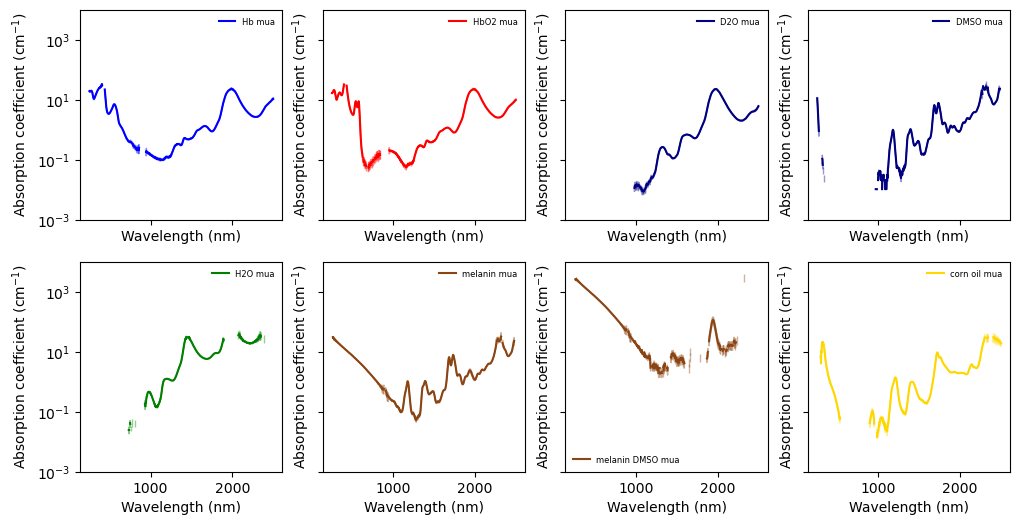

In [12]:


#---------------------------------------------------------------------------------------------------------------------------------
# plot data
colours = ['b', 'r', 'navy', 'navy', 'g', 'saddlebrown', 'saddlebrown', 'gold']

list_mua = ["Hb mua", "HbO2 mua", "D2O mua", "DMSO mua", "H2O mua", "melanin mua", "melanin DMSO mua", "corn oil mua"]

list_std = ["Hb std", "HbO2 std", "D2O std", "DMSO std", "H2O std", "melanin std", "melanin DMSO std", "corn oil std"]

fig, axes = plt.subplots(ncols=4,nrows=2, sharex=True, sharey=True, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.set_yscale("log")
    ax.set_ylim(0.001, 10000)
    ax.plot(df_merged.index, df_merged[list_mua[i]], ls='-', c=colours[i], label=list_mua[i])
    ax.fill_between(df_merged.index, df_merged[list_mua[i]]-df_merged[list_std[i]],  df_merged[list_mua[i]]+df_merged[list_std[i]], color=colours[i], alpha=0.4)
    ax.set_ylabel('Absorption coefficient (cm$^{-1})$')
    ax.set_xlabel('Wavelength (nm)')
    ax.legend(loc=0, frameon=False, fontsize=6)
    
plt.show()


# Data collected with in-house SIS (developed by Ran Tao), raw data processed with IAD

Load CSV files containing IAD data
Also, stiching the diluted and whole blood together

In [13]:
# Co-polymer-in-oil phantoms

path_cp = BASE_PATH + 'Data/in-house-SIS/Co-polymer-in-oil_MJW/Co-polymer-in-oil_MJW.csv'
df_cp = IAD(path_cp, 'copolymer')

# Agar phantoms
path_agar = BASE_PATH + 'Data/in-house-SIS/Agar_MJW/Agar_MJW.csv'
df_agar = IAD(path_agar, 'agar') 

# PDMS phantoms
path_PDMS = BASE_PATH + 'Data/in-house-SIS/PDMS_MJW/PDMS_MJW.csv'
df_PDMS = IAD(path_PDMS, 'PDMS')

# Lard
path_lard = BASE_PATH + 'Data/in-house-SIS/Lard_MJW/Lard_MJW.csv'
df_lard = IAD(path_lard, 'lard')

# Whole blood, raw (not chemically oxygenated) (WB_oxy)
path_WB_oxy = BASE_PATH + 'Data/in-house-SIS/Raw_whole_blood_MJW/Raw_whole_blood_MJW.csv'
df_WB_oxy = IAD(path_WB_oxy, 'WB oxy')
df_WB_oxy = df_WB_oxy[df_WB_oxy['nm'] >= 600] # remove where it didn't converge properly due to low T

# Whole blood, deoxygenated (chemically with sodium dithionite) (WB_deoxy)
path_WB_deoxy = BASE_PATH + 'Data/in-house-SIS/Deoxy_whole_blood_MJW/Deoxy_whole_blood_MJW.csv'
df_WB_deoxy = IAD(path_WB_deoxy, 'WB deoxy')
df_WB_deoxy = df_WB_deoxy[df_WB_deoxy['nm'] >= 600] # remove where it didn't converge properly due to low T

# 1% whole blood, raw (not chemically oxygenated) (1pc_oxy)
path_1pc_oxy = BASE_PATH + 'Data/in-house-SIS/Raw_1%_blood_MJW/Raw_1%_blood_MJW.csv'
df_1pc_oxy = IAD(path_1pc_oxy, '1pc oxy')

# 1% whole blood, deoxygenated (chemically with sodium dithionite) (1pc_deoxy)
path_1pc_deoxy = BASE_PATH + 'Data/in-house-SIS/Deoxy_1%_blood_MJW/Deoxy_1%_blood_MJW.csv'
df_1pc_deoxy = IAD(path_1pc_deoxy, '1pc deoxy')

# make copies of the 1% whole blood data only keep below 600nm to stitch with the SWIR spectra
df_vis_1pc_oxy = df_1pc_oxy[df_1pc_oxy['nm'] <= 600]
df_vis_1pc_oxy = df_vis_1pc_oxy.rename(columns={"1pc oxy mua": "1pc oxy vis mua", "1pc oxy mua std": "1pc oxy vis mua std", "1pc oxy mus": "1pc oxy vis mus", "1pc oxy mus std": "1pc oxy vis mus std"})
df_vis_1pc_oxy.iloc[:, 1:] = df_vis_1pc_oxy.iloc[:, 1:] * 100 # account for 1% concentration

df_vis_1pc_deoxy = df_1pc_deoxy[df_1pc_deoxy['nm'] <= 600]
df_vis_1pc_deoxy = df_vis_1pc_deoxy.rename(columns={"1pc deoxy mua": "1pc deoxy vis mua", "1pc deoxy mua std": "1pc deoxy vis mua std", "1pc deoxy mus": "1pc deoxy vis mus", "1pc deoxy mus std": "1pc deoxy vis mus std"})
df_vis_1pc_deoxy.iloc[:, 1:] = df_vis_1pc_deoxy.iloc[:, 1:] * 100 # account for 1% concentration

# make df with whole blood stiched to 1% blood (450-1600nm)
df_WB_nm = pd.concat([df_vis_1pc_oxy["nm"], df_WB_oxy["nm"]], axis=0, sort=False)

df_WB_oxy_mua = pd.concat([df_vis_1pc_oxy["1pc oxy vis mua"], df_WB_oxy["WB oxy mua"]], axis=0, sort=False)
df_WB_oxy_mua_std = pd.concat([df_vis_1pc_oxy["1pc oxy vis mua std"], df_WB_oxy["WB oxy mua std"]], axis=0, sort=False)

df_WB_deoxy_mua = pd.concat([df_vis_1pc_deoxy["1pc deoxy vis mua"], df_WB_deoxy["WB deoxy mua"]], axis=0, sort=False)
df_WB_deoxy_mua_std = pd.concat([df_vis_1pc_deoxy["1pc deoxy vis mua std"], df_WB_deoxy["WB deoxy mua std"]], axis=0, sort=False)

df_wholeblood = pd.concat([df_WB_nm, df_WB_oxy_mua, df_WB_oxy_mua_std, df_WB_deoxy_mua, df_WB_deoxy_mua_std], keys=["nm", "WB S oxy mua", "WB S oxy mua std", 
                                                                                            "WB S deoxy mua", "WB S deoxy mua std"], axis=1, sort=False)
# S = stitched
#df_wholeblood



In [14]:
# Rayleigh + Mie theory scattering equation (Jacques 2013, DOI: )
def scattering(wavelengths, mus_at_500_nm, fraction_rayleigh_scattering, mie_power_law_coefficient):
    scattering = (mus_at_500_nm * (fraction_rayleigh_scattering * (wavelengths / 500) ** (-4) +
                      (1 - fraction_rayleigh_scattering) * (wavelengths / 500) ** -mie_power_law_coefficient))
    return scattering

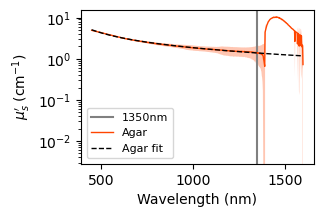

In [15]:
# Fit curve to Agar phantom reduced scattering spectrum (to remove 1400nm water peak)

# crop below 1350nm
df_crop = df_agar
df_crop = df_crop.where(df_crop['nm'] <= 1350, np.nan)
df_crop = df_crop.dropna() 

# fit to Rayleigh + Mie theory scattering equation
popt, pcov = curve_fit(scattering, df_crop['nm'], df_crop['agar musp'])
df_agar_musp_fit = pd.DataFrame({'agar musp fit': scattering(df_agar['nm'], *popt)})
# concatenate fit to df_agar
df_agar = pd.concat([df_agar, df_agar_musp_fit], axis=1, sort=False)

# Plot to check fit
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
plt.rc('font', size=10) 

plt.yscale("log")
plt.ylabel('$\mu_s^{\prime}$ (cm$^{-1}$)')
plt.xlabel('Wavelength (nm)')

plt.axvline(1350, c='grey', label='1350nm')
plt.plot(df_agar['nm'], df_agar['agar musp'], c='orangered', lw=1, ls='-', label='Agar')
plt.fill_between(df_agar['nm'], df_agar['agar musp'] - df_agar['agar musp std'], df_agar['agar musp'] + df_agar['agar musp std'], color='orangered', lw=2, alpha=0.3, edgecolor=None)
plt.plot(df_agar['nm'], df_agar['agar musp fit'], c='k', lw=1, ls='--', label='Agar fit')
plt.legend(loc=0, fontsize=8)
plt.show()

# Combine into one dataframe for plotting / saving

In [16]:
# Merge DataFrames on 'nm' (column 0)

# just including spectra for paper
df_IAD = pd.merge(df_lard, df_wholeblood, on='nm', how='outer')
df_IAD = pd.merge(df_IAD, df_WB_oxy, on='nm', how='outer')
df_IAD = pd.merge(df_IAD, df_WB_deoxy, on='nm', how='outer')
df_IAD = pd.merge(df_IAD, df_cp, on='nm', how='outer')
df_IAD = pd.merge(df_IAD, df_agar, on='nm', how='outer')
df_IAD = pd.merge(df_IAD, df_PDMS, on='nm', how='outer')

# Set 'nm' as the index
df_IAD.set_index('nm', inplace=True)
# sort index so wavelengths are in the right order post merging
df_IAD = df_IAD.sort_index()

df_IAD.columns

df_IAD.to_csv(BASE_PATH + 'Data/in-house-SIS/processed_in-house_spectra.csv', index=True)

# Save data as txt files for SIMPA simulations

In [18]:
# save spectra as individual txt files into a folder for simulations in SIMPA

# ----------------------------------------------------------------------------------------------------------------

# WATER MUA by Segelstein 1981
PATH_water = '/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/Data/Reference_Spectra/water_spectrum.txt'
water_data = pd.read_csv(PATH_water, delimiter='\t', skiprows=1, header=[0]) # in cm-1

water_data = water_data.where(water_data['(nm)'] <= 2000, np.nan)
water_data = water_data.where(water_data['(nm)'] >= 400, np.nan)
water_data = water_data.dropna() 

water_mua_spectra = pd.DataFrame({
    "nm": water_data['(nm)'],
    "mua[cm-1]": water_data['(1/cm)']
})

# Save to a .txt file
water_mua_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'water_mua.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# OXY BLOOD MUA ONLY
oxy_blood_mua_spectra = pd.DataFrame({
    "nm": df_WB_nm,
    "mua[cm-1]": df_WB_oxy_mua
})
# Save to a .txt file
oxy_blood_mua_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'oxy_blood_mua.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# DEOXY BLOOD MUA ONLY
deoxy_blood_mua_spectra = pd.DataFrame({
    "nm": df_WB_nm,
    "mua[cm-1]": df_WB_deoxy_mua
})
# Save to a .txt file
deoxy_blood_mua_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'deoxy_blood_mua.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# LARD MUA and MUSP
lard_spectra = pd.DataFrame({
    "nm": df_lard['nm'],
    "mua[cm-1]": df_lard['lard mua'],
    "musp[cm-1]": df_lard['lard musp']
})
# Save to a .txt file
lard_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'lard_mua_musp.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# CO-POLYMER-IN-OIL PHANTOM MUA AND MUSP
copolymer_spectra = pd.DataFrame({
    "nm": df_cp['nm'],
    "mua[cm-1]": df_cp['copolymer mua'], 
    "musp[cm-1]": df_cp['copolymer musp'],
})
# Save to a .txt file
copolymer_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'copolymer_mua_musp.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# AGAR PHANTOM MUA AND MUSP
agar_spectra = pd.DataFrame({
    "nm": df_agar['nm'],
    "mua[cm-1]": df_agar['agar mua'], 
    "musp[cm-1]": df_agar['agar musp fit'],
})
# Save to a .txt file
agar_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'agar_mua_musp.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# PDMS PHANTOM MUA AND MUSP
PDMS_spectra = pd.DataFrame({
    "nm": df_PDMS['nm'],
    "mua[cm-1]": df_PDMS['PDMS mua'], 
    "musp[cm-1]": df_PDMS['PDMS musp'],
})
# Save to a .txt file
PDMS_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'PDMS_mua_musp.txt', sep='\t', index=False)

# ----------------------------------------------------------------------------------------------------------------

# FAT MUA

# Load van Veen pig fat (VIS - NIR data)
pigfat_file = pd.read_csv(BASE_PATH + 'Data/Reference_Spectra/' + 'fat_spectrum.txt', delimiter='\t', header=[0]) # in m-1 (yes metres)
pigfat_wavelengths = pigfat_file['nm']
pigfat_mua = pigfat_file['mu_a']* 0.01 # convert to cm-1
pigfat = pd.DataFrame({'nm': pigfat_wavelengths, 'mua[cm-1]': pigfat_mua})
pigfat = pigfat.where(pigfat['nm'] <= 1000, np.nan) # remove spectra above 1000nm
pigfat = pigfat.dropna() 

# Lard spectra (measured in this work)
lard = pd.DataFrame({'nm': df_lard['nm'], 'mua[cm-1]': df_lard['lard mua']})
lard = lard.where(lard['nm'] > 1000, np.nan) # remove spectra below 1000nm
lard = lard.dropna()

# Concatenate pig fat and lard spectra
df_fat_SIMPA = pd.concat([pigfat, lard], axis=0, sort=False)

# Save to a .txt file
df_fat_SIMPA.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'fat_mua.txt', sep='\t', index=False)
# ----------------------------------------------------------------------------------------------------------------


# MELANIN - MJW
melanin_mua_spectra = pd.DataFrame({
    "nm": df_merged.index,
    "mua[cm-1]": df_merged['melanin DMSO mua']
})
# Save to a .txt file
melanin_mua_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'melanin_mua.txt', sep='\t', index=False)


# MELANOSOME APPROX - JACQUES
def mu_a_melanosomes_eqn(wavelength):
    return 1.70*10**12*wavelength**(-3.48) #cm-1

melanin_wavelengths = np.linspace(250, 2500, 1000) 
melanin_mua = mu_a_melanosomes_eqn(melanin_wavelengths)

# Combine into a single DataFrame for saving
melanin_spectra = pd.DataFrame({
    "nm": melanin_wavelengths,
    "mua[cm-1]": melanin_mua
})

# Save to a .txt file
melanin_spectra.to_csv(BASE_PATH + 'Data/Reference_Spectra/' + 'melanin_mua_SIMPA_ext.txt', sep='\t', index=False)



In [19]:
# make scattering curves

# literature data from literature_values.py in SIMPA

AP_FAT = 19.3 # Table 2 fatty tissue in Jacques 2013 paper
FRAY_FAT = 0.174  # Table 2 fatty tissue in Jacques 2013 paper
BMIE_FAT = 0.447  # Table 2 fatty tissue in Jacques 2013 paper

MUS500_BLOOD = 1170  # Table 1 Alexandrakis et al 2005
FRAY_BLOOD = 0.0  # Table 1 Alexandrakis et al 2005
BMIE_BLOOD = 0.93  # Table 1 Alexandrakis et al 2005

AP_EPIDERMIS = 66.7  # Table 1; Salomatina et al 2006; One value for epidermis
FRAY_EPIDERMIS = 0.29  # Table 1; Salomatina et al 2006; One value for epidermis
BMIE_EPIDERMIS = 0.689  # Table 1; Salomatina et al 2006; One value for epidermis

AP_DERMIS = 43.6  # Table 1; Salomatina et al 2006; One value for dermis
FRAY_DERMIS = 0.41  # Table 1; Salomatina et al 2006; One value for dermis
BMIE_DERMIS = 0.562  # Table 1; Salomatina et al 2006; One value for dermis

AP_MUSCLE_TISSUE = 19.1  # Table 2: Average over all other soft tissue
FRAY_MUSCLE_TISSUE = 0.153  # Table 2: Average over all other soft tissue
BMIE_MUSCLE_TISSUE = 1.091  # Table 2: Average over all other soft tissue

STANDARD_ANISOTROPY = 0.9  # Average anisotropy of measured values presented in paper
DERMIS_ANISOTROPY = 0.715
BLOOD_ANISOTROPY = 0.98


# DEFINE WAVLENGTH REGION TO EXTRAPOLATE TO
# note Jccques 2013 says this applies to 400nm - 1300nm only
musp_wavelengths = np.linspace(450, 1600, 1150)

# BLOOD
musp_blood = scattering(musp_wavelengths, MUS500_BLOOD, FRAY_BLOOD, BMIE_BLOOD)*(1-0.98)

# FAT
musp_fat = scattering(musp_wavelengths, AP_FAT, FRAY_FAT, BMIE_FAT)

# EPIDERMIS
musp_epidermis = scattering(musp_wavelengths, AP_EPIDERMIS, FRAY_EPIDERMIS, BMIE_EPIDERMIS)

# DERMIS
musp_dermis = scattering(musp_wavelengths, AP_DERMIS, FRAY_DERMIS, BMIE_DERMIS)

# MUSCLE
musp_muscle = scattering(musp_wavelengths, AP_MUSCLE_TISSUE, FRAY_MUSCLE_TISSUE, BMIE_MUSCLE_TISSUE)


#------------------------------------------------------------------------------------------------------------------------------------
# Combine into a single DataFrame for saving
# BLOOD
blood_musp_spectra = pd.DataFrame({
    "nm": musp_wavelengths,
    "musp[cm-1]": musp_blood
})
# FAT
fat_musp_spectra = pd.DataFrame({
    "nm": musp_wavelengths,
    "musp[cm-1]": musp_fat
})
# EPIDERMIS
epidermis_musp_spectra = pd.DataFrame({
    "nm": musp_wavelengths,
    "musp[cm-1]": musp_epidermis
})
# DERMIS
dermis_musp_spectra = pd.DataFrame({
    "nm": musp_wavelengths,
    "musp[cm-1]": musp_dermis
})
# MUSCLE
muscle_musp_spectra = pd.DataFrame({
    "nm": musp_wavelengths,
    "musp[cm-1]": musp_muscle
})
# Save to a .txt files
# FAT
fat_musp_spectra.to_csv(BASE_PATH + 'Data/Reference_Spectra/' + 'fat_musp.txt', sep='\t', index=False) # to comapre to measured lard
fat_musp_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'fat_musp.txt', sep='\t', index=False) # for simulations
# BLOOD
blood_musp_spectra.to_csv(BASE_PATH + 'Data/Reference_Spectra/' + 'blood_musp.txt', sep='\t', index=False) # to comapre to measured whole blood
blood_musp_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'blood_musp.txt', sep='\t', index=False) # for simulations
# EPIDERMIS
epidermis_musp_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'epidermis_musp.txt', sep='\t', index=False)
# DERMIS
dermis_musp_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'dermis_musp.txt', sep='\t', index=False)
# MUSCLE
muscle_musp_spectra.to_csv(BASE_PATH + 'Data/Simulation_Spectra/' + 'muscle_musp.txt', sep='\t', index=False)


     mua[cm-1]           nm
0     0.082800   429.000000
1     0.082160   430.000000
2     0.081580   431.000000
3     0.080690   432.000000
4     0.079270   433.000000
..         ...          ...
204  41.383044  2302.267206
205  46.084131  2310.526316
206  39.215517  2312.591093
207  34.838229  2314.655870
208  30.618317  2318.785425

[889 rows x 2 columns]


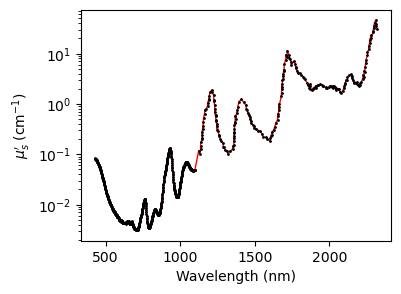

In [20]:
# create continuous vis-SWIR pig + human fat reference spectrum for statistical analysis

# pig fat ref by van Veen (to 1098nm)
pigfat_ref = pd.DataFrame({'nm': pigfat_wavelengths, 'mua[cm-1]': pigfat_mua})


# Human fat - Anderson 2006 (from ~1123nm)
PATH_humanfat = BASE_PATH + 'Data/Reference_Spectra/Anderson2006_fat_muaspectrum.csv'
humanfat_mua_ref = pd.read_csv(PATH_humanfat, sep=',', header=[0])
humanfat_mua_ref = humanfat_mua_ref.sort_values(by='nm')

humanfat_ref = pd.DataFrame({'nm': humanfat_mua_ref['nm'], 'mua[cm-1]': humanfat_mua_ref['cm-1']})

# Concatenate pig fat and lard spectra
df_fat_ref = pd.concat([pigfat_ref, humanfat_ref], axis=0, sort=True)

print(df_fat_ref)

# Plot to check
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plt.rc('font', size=10) 

plt.yscale("log")
plt.ylabel('$\mu_s^{\prime}$ (cm$^{-1}$)')
plt.xlabel('Wavelength (nm)')

plt.plot(df_fat_ref['nm'], df_fat_ref['mua[cm-1]'], c='r', lw=1, ls='-')
plt.plot(df_fat_ref['nm'], df_fat_ref['mua[cm-1]'], c='k', lw=1, ls='', marker='.', markersize=2)

plt.show()

# Save to a .txt file
df_fat_ref.to_csv(BASE_PATH + 'Data/Reference_Spectra/' + 'pig_and_human_fat_mua.txt', sep='\t', index=False)